In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
train_transform = transforms.Compose([
    transforms.RandomRotation(15),  # Случайный поворот на угол до 15 градусов
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Расширенный ColorJitter
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))])

In [3]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))])

In [4]:
train_data = datasets.CIFAR100(root='./data', train=True, download=True, transform=train_transform)
test_data  = datasets.CIFAR100(root='./data', train=False, download=True, transform=test_transform)

100%|██████████| 169M/169M [32:08<00:00, 87.6kB/s]


In [5]:
train = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=2)
test  = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=2)

In [6]:
classes = train_data.classes
print(classes)

['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree',

In [7]:
len(classes)

100

In [8]:
mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3, 1, 1)
std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1)

In [9]:
def imshow_denorm(img, title=None):
    img = img * std + mean
    img = torch.clamp(img, 0, 1)
    plt.imshow(img.permute(1, 2, 0))
    if title:
        plt.title(title)
    plt.axis('off')

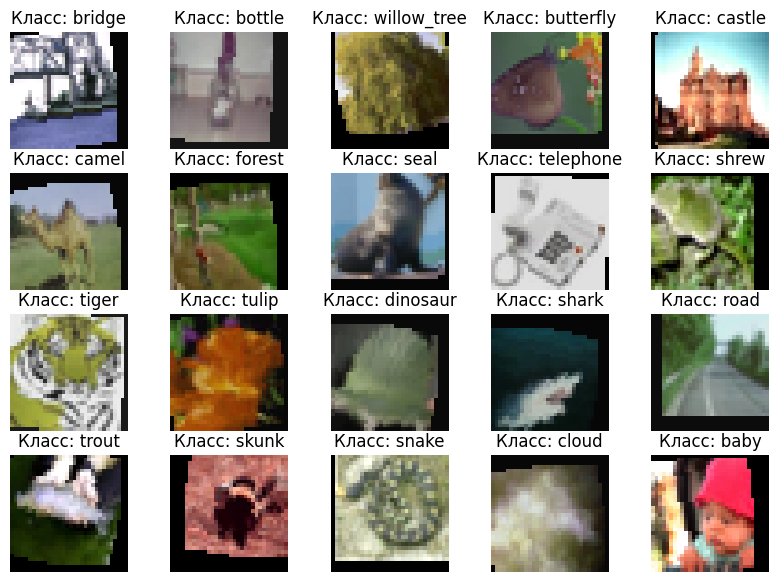

In [10]:
image, label = next(iter(train))
plt.figure(figsize=(10, 10))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    imshow_denorm(image[i], title=f'Класс: {classes[label[i]]}')
plt.subplots_adjust(top=0.65)
plt.savefig('test2')
plt.show()

In [11]:
class Cifar100Classification(nn.Module): # VGG
    def __init__(self):
        super().__init__()

        # Блок 1: 32x32 -> 16x16 (без изменений)
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.1)
        )

        # Блок 2: 16x16 -> 8x8 (без изменений)
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.2)
        )

        # Блок 3: 8x8 -> 8x8 (замена MaxPool на AdaptiveAvgPool2d)
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            # Вместо nn.MaxPool2d(2) и nn.Dropout2d(0.3)
            nn.AdaptiveAvgPool2d((1, 1)), # усредняем карту признаков до 1x1
            nn.Dropout(0.3)
        )

        # Classifier (упрощенный, адаптированный под AdaptiveAvgPool2d)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.5), # Можно немного увеличить дропаут здесь
            nn.Linear(512, 100)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [13]:
model_Cifar100Classification  = Cifar100Classification().to(device)

In [14]:
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model_Cifar100Classification.parameters(), lr=1e-3, weight_decay=1e-4)

In [15]:
num_epochs = 100
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5) # eta_min для плавного затухания

train_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    model_Cifar100Classification.train()
    total_loss = 0
    for x_batch, y_batch in train:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        y_pred = model_Cifar100Classification(x_batch)
        loss = loss_fn(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train)
    train_losses.append(avg_train_loss)

    current_lr = scheduler.get_last_lr()[0]
    scheduler.step()

    print(f'Эпоха: {epoch + 1:>3} | Train Loss: {avg_train_loss:.4f} | LR: {current_lr:.6f}')

Эпоха:   1 | Train Loss: 4.1782 | LR: 0.001000
Эпоха:   2 | Train Loss: 3.8387 | LR: 0.001000
Эпоха:   3 | Train Loss: 3.6067 | LR: 0.000999
Эпоха:   4 | Train Loss: 3.4149 | LR: 0.000998
Эпоха:   5 | Train Loss: 3.2835 | LR: 0.000996
Эпоха:   6 | Train Loss: 3.1696 | LR: 0.000994
Эпоха:   7 | Train Loss: 3.0648 | LR: 0.000991
Эпоха:   8 | Train Loss: 2.9799 | LR: 0.000988
Эпоха:   9 | Train Loss: 2.8960 | LR: 0.000984
Эпоха:  10 | Train Loss: 2.8243 | LR: 0.000980
Эпоха:  11 | Train Loss: 2.7712 | LR: 0.000976
Эпоха:  12 | Train Loss: 2.7095 | LR: 0.000971
Эпоха:  13 | Train Loss: 2.6579 | LR: 0.000965
Эпоха:  14 | Train Loss: 2.6134 | LR: 0.000959
Эпоха:  15 | Train Loss: 2.5786 | LR: 0.000953
Эпоха:  16 | Train Loss: 2.5344 | LR: 0.000946
Эпоха:  17 | Train Loss: 2.5130 | LR: 0.000939
Эпоха:  18 | Train Loss: 2.4725 | LR: 0.000931
Эпоха:  19 | Train Loss: 2.4483 | LR: 0.000923
Эпоха:  20 | Train Loss: 2.4249 | LR: 0.000914
Эпоха:  21 | Train Loss: 2.3912 | LR: 0.000905
Эпоха:  22 | 

In [16]:
model_Cifar100Classification.eval()
correct = 0
total = 0

with torch.no_grad():
    for x_batch, y_batch in test:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        prediction = torch.argmax(model_Cifar100Classification(x_batch), dim=1)
        total += y_batch.size(0)
        correct += (prediction == y_batch).sum().item()

test_accuracy = 100 * correct / total
print(f'Точность на тесте: {test_accuracy:.2f}%')

Точность на тесте: 70.04%


In [17]:
def get_accuracy(data_loader):
    model_Cifar100Classification.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            y_pred = model_Cifar100Classification(x_batch)
            prediction = torch.argmax(y_pred, dim=1)
            total += y_batch.size(0)
            correct += (prediction == y_batch).sum().item()
    return round(correct * 100 / total, 2)

print(f'Финишная точность на train: {get_accuracy(train)}%')
print(f'Финишная точность на test: {get_accuracy(test)}%')

Финишная точность на train: 81.33%
Финишная точность на test: 70.04%


In [18]:
from google.colab import files

torch.save(model_Cifar100Classification.state_dict(), 'model_Cifar100Classification_CIFAR_100.pth')

files.download('model_Cifar100Classification_CIFAR_100.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
classes = train_data.classes
print(classes)

['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree',